In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cdc_ml.config import POLLS_PROCESSED,PREFERENCE_PROCESSED,CUSTOMER_CLASS_PROCESSED
from cdc_ml.modeling.train import StratifiedUsernameKFold,rs_pr_auc
from cdc_ml.features.build_features import build_features,get_whale_users
from cdc_ml.features.config import FEATS_ABL_LIST
from cdc_ml.modeling.evaluation import model_comparison, paired_t,pr_auc_ci_by_user,adversarial_validation,per_customer_at_budget
from cdc_ml.modeling.calibrate import fit_platt_scaler,calibrate_proba
from cdc_ml.plots import plot_calibration_by_volume,bootstrapped_gain_curve
import joblib


2026-06-05 12:59:27.128 | INFO     | cdc_ml.config:<module>:12 - PROJ_ROOT path is: C:\Users\zhiju\Desktop\cdc_ml


In [2]:
df = pd.read_parquet(POLLS_PROCESSED)
df_pref = pd.read_parquet(PREFERENCE_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)

In [3]:
df = build_features(df,df_pref,df_class)

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 32492 entries, 1126 to 32034
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype                         
---  ------                --------------  -----                         
 0   id                    32492 non-null  int64                         
 1   username              32492 non-null  str                           
 2   cycle_start           32492 non-null  datetime64[us, Asia/Singapore]
 3   cycle_end             32492 non-null  datetime64[us, Asia/Singapore]
 4   polling_at            32492 non-null  datetime64[us, Asia/Singapore]
 5   has_booking           32492 non-null  bool                          
 6   cycle_start_month     32492 non-null  int32                         
 7   cycle_start_day       32492 non-null  int32                         
 8   cycle_start_dow       32492 non-null  int32                         
 9   cycle_start_hour      32492 non-null  int32                         
 10  polling_mon

In [5]:
df.describe()

,id,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,polling_month,polling_day,polling_dow,polling_hour,hours_into_cycle,...,pref_unique_day,pref_unique_timeslot,pref_dow_count_0,pref_dow_count_1,pref_dow_count_2,pref_dow_count_3,pref_dow_count_4,pref_dow_count_5,pref_dow_count_6,countdown
count,32492.000000,32492.000000,32492.000000,32492.000000,32492.000000,32492.000000,32492.000000,32492.000000,32492.000000,32492.000000,...,32351.000000,32351.000000,32351.000000,32351.000000,32351.000000,32351.000000,32351.000000,32351.000000,32351.000000,32351.000000
mean,60.759356,7.361197,14.999446,2.543395,7.544042,7.023175,15.327219,2.972978,11.564970,241.788315,...,5.099471,5.082749,3.079132,3.151649,2.820222,3.080059,3.198077,3.395629,3.790455,260.712374
std,36.137647,4.191270,8.899747,1.788240,8.323271,4.332249,8.671690,1.977111,6.929176,244.844490,...,1.998824,2.115063,2.640169,2.631236,2.718137,2.708911,2.558295,3.110283,3.168696,470.060921
min,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,-0.950000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1415.000000
25%,28.000000,3.000000,8.000000,1.000000,0.000000,2.000000,8.000000,1.000000,6.000000,72.000000,...,3.000000,3.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,61.000000,10.000000,14.000000,2.000000,1.000000,9.000000,15.000000,3.000000,12.000000,171.000000,...,5.000000,6.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,5.000000,108.000000
75%,94.000000,11.000000,22.000000,4.000000,16.000000,11.000000,23.000000,5.000000,18.000000,321.000000,...,7.000000,7.000000,6.000000,6.000000,6.000000,7.000000,6.000000,7.000000,7.000000,588.000000
max,121.000000,12.000000,31.000000,6.000000,23.000000,12.000000,31.000000,6.000000,23.000000,1523.233333,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,1560.000000


In [6]:
df.head()

,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,...,pref_dow_count_0,pref_dow_count_1,pref_dow_count_2,pref_dow_count_3,pref_dow_count_4,pref_dow_count_5,pref_dow_count_6,pref_start,pref_end,countdown
1126,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-12 06:00:00+08:00,False,8,12,1,1,...,2.0,2.0,2.0,2.0,1.0,3.0,3.0,2025-08-18 00:00:00+08:00,2025-10-09 00:00:00+08:00,1248.0
1218,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-16 02:00:00+08:00,False,8,12,1,1,...,2.0,2.0,2.0,2.0,1.0,3.0,3.0,2025-08-18 00:00:00+08:00,2025-10-09 00:00:00+08:00,1248.0
1217,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-16 01:00:00+08:00,False,8,12,1,1,...,2.0,2.0,2.0,2.0,1.0,3.0,3.0,2025-08-18 00:00:00+08:00,2025-10-09 00:00:00+08:00,1248.0
1216,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-16 00:00:00+08:00,False,8,12,1,1,...,2.0,2.0,2.0,2.0,1.0,3.0,3.0,2025-08-18 00:00:00+08:00,2025-10-09 00:00:00+08:00,1248.0
1215,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-15 23:00:00+08:00,False,8,12,1,1,...,2.0,2.0,2.0,2.0,1.0,3.0,3.0,2025-08-18 00:00:00+08:00,2025-10-09 00:00:00+08:00,1248.0


In [7]:
df_train, df_test = StratifiedUsernameKFold(df)


Train share -> 0.7963190939308138
Test share -> 0.20368090606918626
Baseline positive rate -> 0.012187615413024745
Train positive rate -> 0.012483574244415242
Test positive rate -> 0.011030522816560894


In [8]:
df_train.head(1)

,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,...,pref_dow_count_0,pref_dow_count_1,pref_dow_count_2,pref_dow_count_3,pref_dow_count_4,pref_dow_count_5,pref_dow_count_6,pref_start,pref_end,countdown
1126,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-12 06:00:00+08:00,False,8,12,1,1,...,2.0,2.0,2.0,2.0,1.0,3.0,3.0,2025-08-18 00:00:00+08:00,2025-10-09 00:00:00+08:00,1248.0


In [9]:
xgb_pr_auc = rs_pr_auc(df_train,FEATS_ABL_LIST,1)

fold 0: train n= 20681 val n=  5193   train_pos=0.013  val_pos=0.011
  marg_dow  brier=0.0105  pr=0.0128
  marg_hour brier=0.0104  pr=0.0212
  add       brier=0.0104  pr=0.0247
  joint     brier=0.0105  pr=0.0253
  rf        brier=0.0104  pr=0.0251
  xgb (val) brier=0.0104  pr=0.0245
  xgb (tr)  brier=0.0126  pr=0.0346

fold 1: train n= 20390 val n=  5484   train_pos=0.014  val_pos=0.007
  marg_dow  brier=0.0071  pr=0.0088
  marg_hour brier=0.0072  pr=0.0093
  add       brier=0.0072  pr=0.0114
  joint     brier=0.0073  pr=0.0102
  rf        brier=0.0073  pr=0.0113
  xgb (val) brier=0.0072  pr=0.0107
  xgb (tr)  brier=0.0135  pr=0.0395

fold 2: train n= 20955 val n=  4919   train_pos=0.011  val_pos=0.021
  marg_dow  brier=0.0204  pr=0.0256
  marg_hour brier=0.0202  pr=0.0390
  add       brier=0.0201  pr=0.0514
  joint     brier=0.0203  pr=0.0380
  rf        brier=0.0202  pr=0.0439
  xgb (val) brier=0.0201  pr=0.0500
  xgb (tr)  brier=0.0103  pr=0.0270

fold 3: train n= 20706 val n=  516

In [10]:
print(model_comparison(xgb_pr_auc))

                                model      mean  std
0                            baseline  0.023866  0.0
1                   baseline+pref_dow  0.047537  0.0
2            baseline+pref_unique_day  0.033365  0.0
3       baseline+pref_unique_timeslot  0.036664  0.0
4              baseline+pref_coverage  0.049464  0.0
5                  baseline+countdown  0.028976  0.0
6                 baseline+uday+utime  0.046376  0.0
7                     baseline+cov+cd  0.059248  0.0
8      baseline+uday+utime+cd+cov+cls  0.076662  0.0
9  baseline+uday+utime+cd+cov+cls+dow  0.068716  0.0


In [11]:
chosen = "baseline+uday+utime+cd+cov+cls"
chosen_2 = "baseline+uday+utime+cd+cov+cls+dow"

In [12]:
d,t,p,ci,n_pos= paired_t(xgb_pr_auc,chosen,chosen_2)

print(f"d:{d}\n t:{t}\n p:{p}\n ci:{ci}\n")

1
d:0.007945502976055674
 t:nan
 p:nan
 ci:(np.float64(nan), np.float64(nan))



c:\Users\zhiju\Desktop\cdc_ml\.venv\Lib\site-packages\scipy\stats\_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
c:\Users\zhiju\Desktop\cdc_ml\.venv\Lib\site-packages\scipy\stats\_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
c:\Users\zhiju\Desktop\cdc_ml\.venv\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\zhiju\Desktop\cdc_ml\.venv\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [13]:
xgb_pr_auc_6 = rs_pr_auc(df_train,FEATS_ABL_LIST,1,m_depth=6,min_child=20)

fold 0: train n= 20681 val n=  5193   train_pos=0.013  val_pos=0.011
  marg_dow  brier=0.0105  pr=0.0128
  marg_hour brier=0.0104  pr=0.0212
  add       brier=0.0104  pr=0.0247
  joint     brier=0.0105  pr=0.0253
  rf        brier=0.0104  pr=0.0251
  xgb (val) brier=0.0104  pr=0.0243
  xgb (tr)  brier=0.0126  pr=0.0340

fold 1: train n= 20390 val n=  5484   train_pos=0.014  val_pos=0.007
  marg_dow  brier=0.0071  pr=0.0088
  marg_hour brier=0.0072  pr=0.0093
  add       brier=0.0072  pr=0.0114
  joint     brier=0.0073  pr=0.0102
  rf        brier=0.0073  pr=0.0113
  xgb (val) brier=0.0072  pr=0.0105
  xgb (tr)  brier=0.0135  pr=0.0388

fold 2: train n= 20955 val n=  4919   train_pos=0.011  val_pos=0.021
  marg_dow  brier=0.0204  pr=0.0256
  marg_hour brier=0.0202  pr=0.0390
  add       brier=0.0201  pr=0.0514
  joint     brier=0.0203  pr=0.0380
  rf        brier=0.0202  pr=0.0439
  xgb (val) brier=0.0201  pr=0.0505
  xgb (tr)  brier=0.0103  pr=0.0269

fold 3: train n= 20706 val n=  516

In [14]:
print(model_comparison(xgb_pr_auc_6))

                                model      mean  std
0                            baseline  0.024177  0.0
1                   baseline+pref_dow  0.046159  0.0
2            baseline+pref_unique_day  0.033627  0.0
3       baseline+pref_unique_timeslot  0.034027  0.0
4              baseline+pref_coverage  0.048400  0.0
5                  baseline+countdown  0.029323  0.0
6                 baseline+uday+utime  0.047155  0.0
7                     baseline+cov+cd  0.048764  0.0
8      baseline+uday+utime+cd+cov+cls  0.071543  0.0
9  baseline+uday+utime+cd+cov+cls+dow  0.064010  0.0


In [15]:
d,t,p,ci,n_pos= paired_t(xgb_pr_auc_6,chosen,chosen_2)

print(f"d:{d}\n t:{t}\n p:{p}\n ci:{ci}\n")

1
d:0.007533126939298168
 t:nan
 p:nan
 ci:(np.float64(nan), np.float64(nan))



c:\Users\zhiju\Desktop\cdc_ml\.venv\Lib\site-packages\scipy\stats\_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
c:\Users\zhiju\Desktop\cdc_ml\.venv\Lib\site-packages\scipy\stats\_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
c:\Users\zhiju\Desktop\cdc_ml\.venv\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\zhiju\Desktop\cdc_ml\.venv\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [16]:
chosen_features = FEATS_ABL_LIST[chosen]
X_train, y_train = df_train[chosen_features],df_train["has_booking"].to_numpy()

X_test, y_test = df_test[chosen_features], df_test["has_booking"].to_numpy()

In [17]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold,GridSearchCV

# X = chosen feature set (polling_dow, polling_hour, pref_*)
# y = has_booking ; groups = df["username"]

base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    n_jobs=1,            # let the search parallelize instead
    random_state=42,
    # scale_pos_weight left at 1 on purpose — see note
)

param_dist = {
    "n_estimators":     [200, 400, 600, 800],
    "max_depth":        [2,3, 4, 5, 6],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "min_child_weight": [1, 5, 10, 20, 50],
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 1.0],     # near no-op with so few features
    "reg_lambda": [1, 5, 10,20],   # default is 1, so right now you're only sampling that one point
    "gamma":            [0, 0.5, 1.0, 2.0],
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

search = RandomizedSearchCV(
    base, param_dist, n_iter=50,
    scoring="average_precision",        # = PR-AUC, your reported metric
    cv=cv, n_jobs=-1, random_state=42, refit=True, verbose=1,
)
#search.fit(df_train[baseline+pref_unique_day+pref_unique_timeslot+pref_days_count+pref_coverage], df_train["has_booking"], groups=df_train["username"])
search.fit(X_train, y_train, groups=df_train["username"])

print(search.best_score_, search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
0.08279290890379391 {'subsample': 0.9, 'reg_lambda': 5, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 1.0, 'colsample_bytree': 0.8}


In [18]:
final_model = search.best_estimator_

In [19]:
whales_pc,_ = get_whale_users()
whales_pt_mask_train = df_train["username"].isin(whales_pc).to_numpy()
non_whales_pt_mask_train = ~df_train["username"].isin(whales_pc).to_numpy()

whales_pt_mask_test = df_test["username"].isin(whales_pc).to_numpy()
non_whales_pt_mask_test = ~df_test["username"].isin(whales_pc).to_numpy()

In [20]:

p_raw = final_model.predict_proba(X_test)[:, 1]

whale_users = df_test.loc[whales_pt_mask_test,["username"]]
non_whales_users = df_test.loc[non_whales_pt_mask_test,["username"]]
print("ALL");        pr_auc_ci_by_user(y_test, p_raw, df_test["username"])
print("WHALES");     pr_auc_ci_by_user(y_test[whales_pt_mask_test],  p_raw[whales_pt_mask_test],  whale_users)
print("NON-WHALES"); pr_auc_ci_by_user(y_test[~whales_pt_mask_test], p_raw[~whales_pt_mask_test], non_whales_users)

ALL
users=8 rows=6618 positives=73 base=0.0110
PR-AUC=0.0323 (2.93x)  95% CI=[0.0155, 0.0661] ([1.40x, 6.00x])

WHALES
users=1 rows=2362 positives=37 base=0.0157
PR-AUC=0.0882 (5.63x)  95% CI=[0.0882, 0.0882] ([5.63x, 5.63x])

NON-WHALES
users=7 rows=4256 positives=36 base=0.0085
PR-AUC=0.0164 (1.94x)  95% CI=[0.0138, 0.0341] ([1.63x, 4.03x])



In [21]:
clf = adversarial_validation(X_train, X_test)
print(
        pd.Series(clf.feature_importances_, index=[chosen_features])
        .sort_values(ascending=False)
        .head(8)
        .to_string()
    )


adversarial AUC = 0.908   (0.5 = identical, ~0.65+ = real shift, 0.8+ = strong)
pref_coverage           0.262112
countdown               0.252168
pref_unique_timeslot    0.141608
pref_unique_day         0.138033
class_type              0.124660
is_one_team             0.061427
polling_dow             0.015775
polling_hour            0.004218


In [22]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict

oof_proba = cross_val_predict(
    clone(final_model), X_train,y_train,
    groups=df_train["username"], cv=cv, method="predict_proba", n_jobs=-1,
)[:, 1]

platt = fit_platt_scaler(oof_proba,y_train)


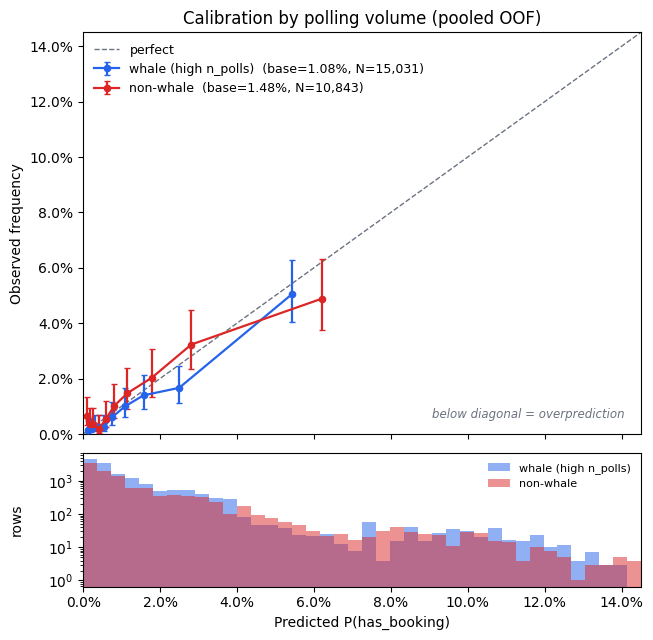

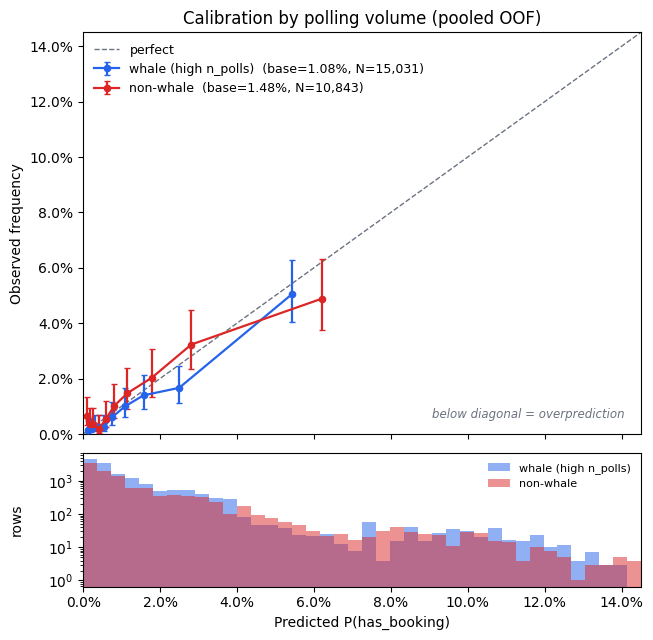

In [23]:
plot_calibration_by_volume(oof_proba,y_train,whales_pt_mask_train)

[0.00349579 0.00153775 0.00153775 ... 0.00040572 0.00040572 0.00040572]


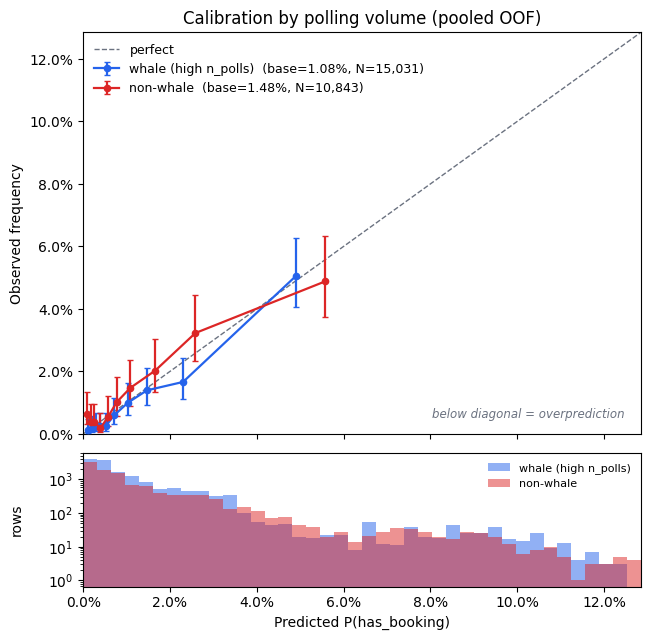

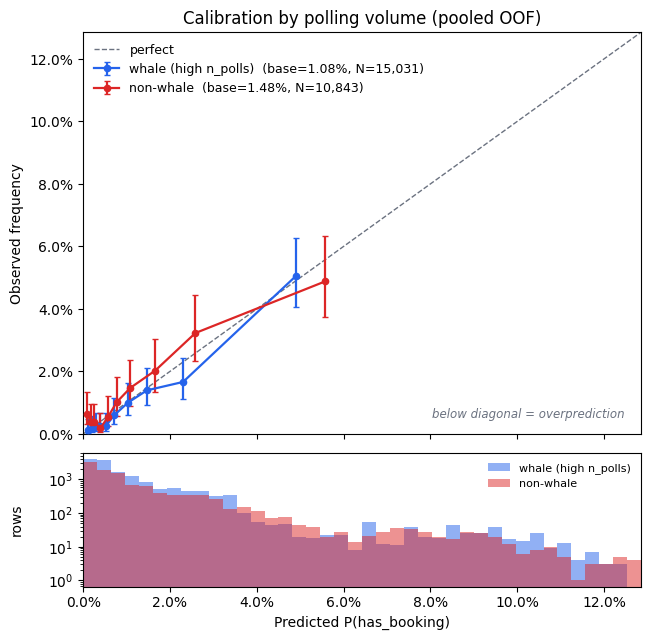

In [24]:
p_train_cal = calibrate_proba(oof_proba,platt)
print(p_train_cal)
plot_calibration_by_volume(p_train_cal,y_train,whales_pt_mask_train)

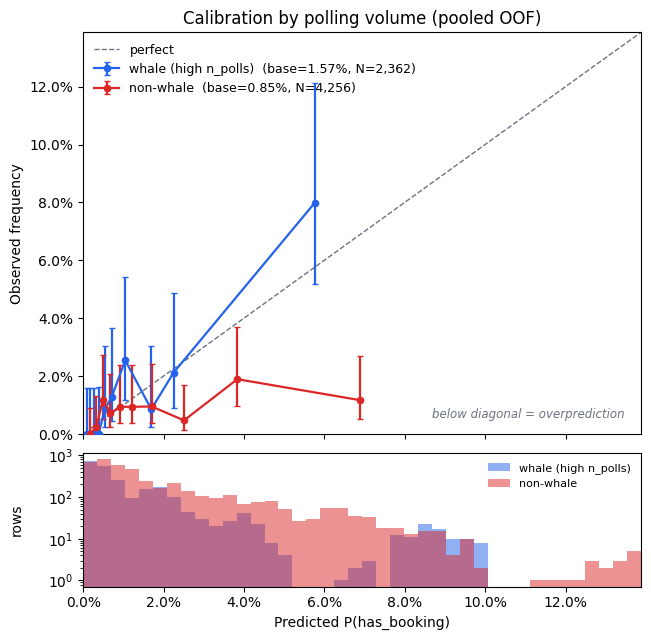

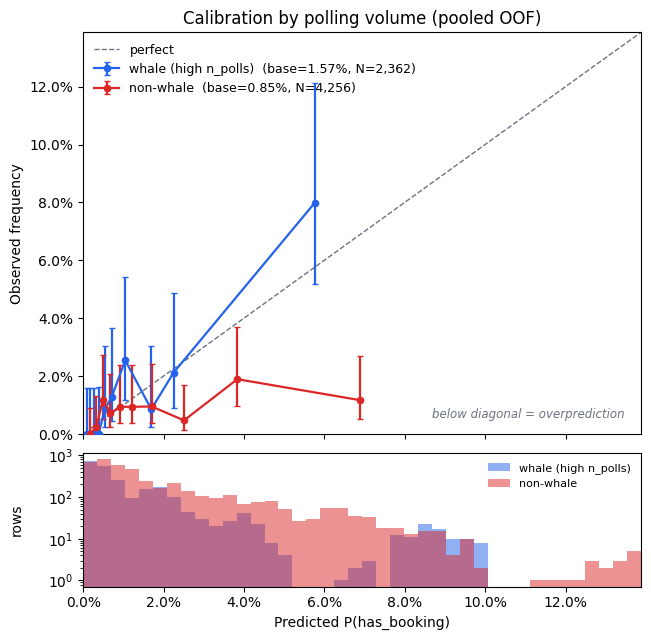

In [25]:
# Train Platt calibrator on OOF predictions
# Raw test predictions

p_test_cal = calibrate_proba(p_raw,platt)

plot_calibration_by_volume(
    p_test_cal,
    df_test["has_booking"].to_numpy(),
    whales_pt_mask_test
)

 booking whales: median recall 86%, worst 86%  (n=1)
       the rest: median recall 89%, worst 0%  (n=7)


<Axes: xlabel='whale', ylabel='recall'>

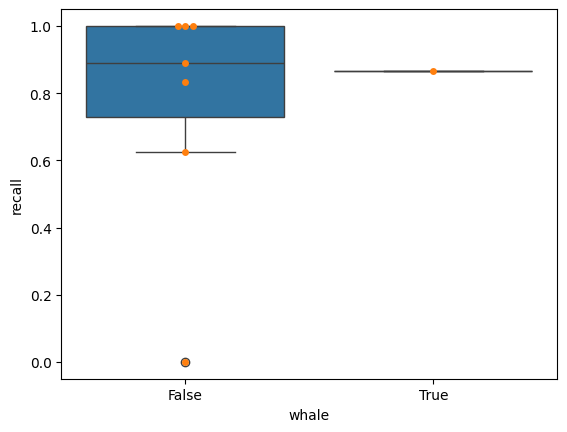

In [26]:
t = per_customer_at_budget(df_test, p_test_cal, budget=0.50)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
sns.boxplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary
sns.swarmplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary

 booking whales: median recall 99%, worst 94%  (n=4)
       the rest: median recall 100%, worst 0%  (n=25)


<Axes: xlabel='whale', ylabel='recall'>

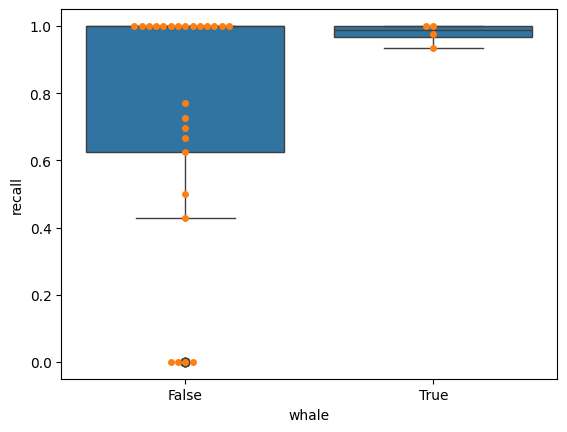

In [27]:

t = per_customer_at_budget(df_train, p_train_cal, budget=0.50)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
sns.boxplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary
sns.swarmplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary

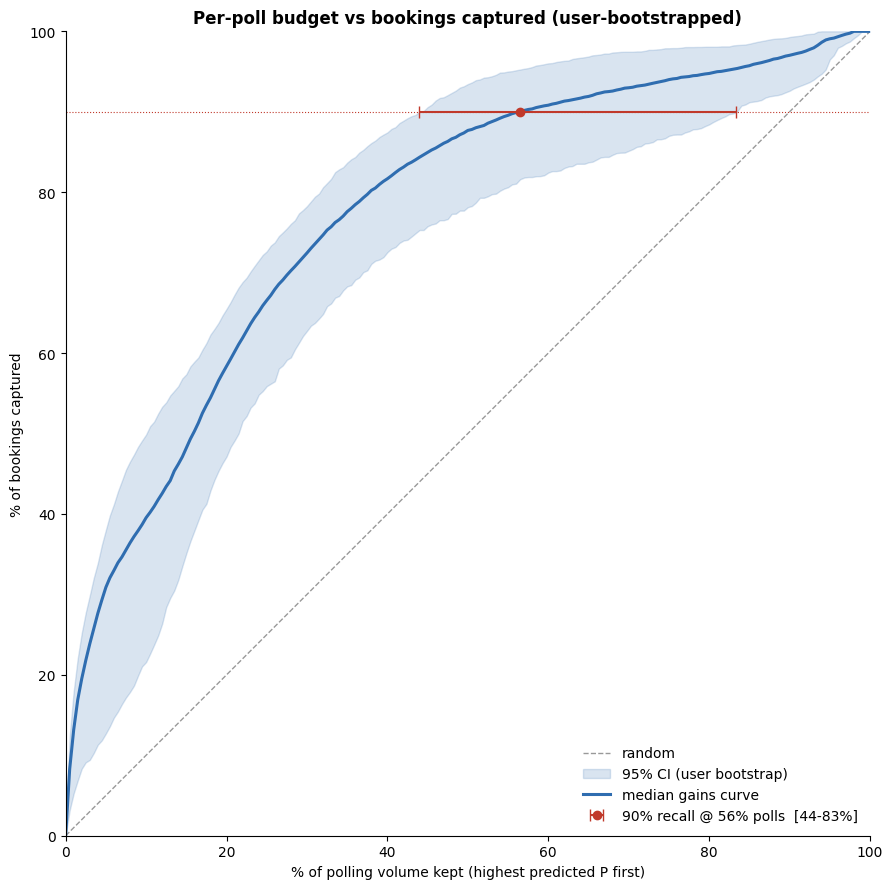

90% of bookings for 56% of polls (95% CI 44-83%)


In [28]:
fig, res = bootstrapped_gain_curve(df_train, p_train_cal)
plt.show()  # or fig.savefig(...) 
print(f"90% of bookings for {res['budget']*100:.0f}% of polls (95% CI {res['budget_ci'][0]*100:.0f}-{res['budget_ci'][2]*100:.0f}%)")

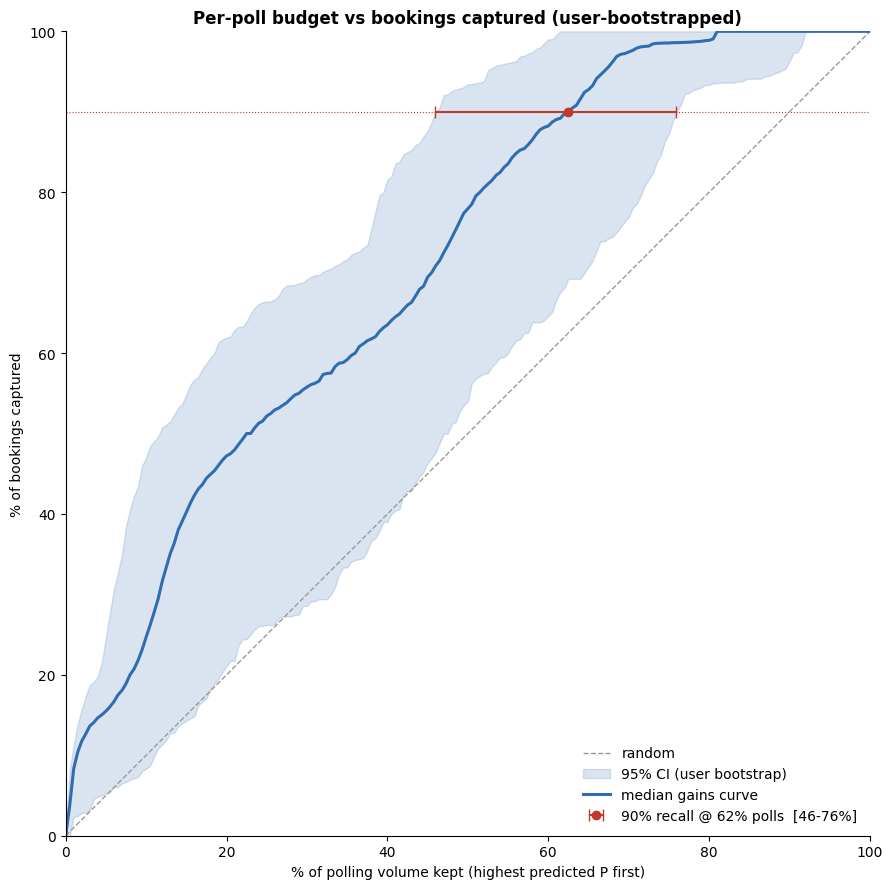

90% of bookings for 63% of polls (95% CI 46-76%)


In [31]:
fig, res = bootstrapped_gain_curve(df_test, p_test_cal)
plt.show()  # or fig.savefig(...) 
print(f"90% of bookings for {res['budget']*100:.0f}% of polls (95% CI {res['budget_ci'][0]*100:.0f}-{res['budget_ci'][2]*100:.0f}%)")

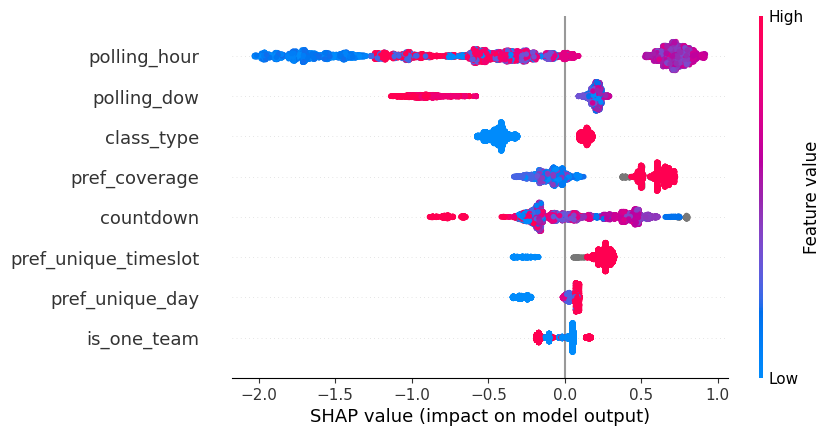

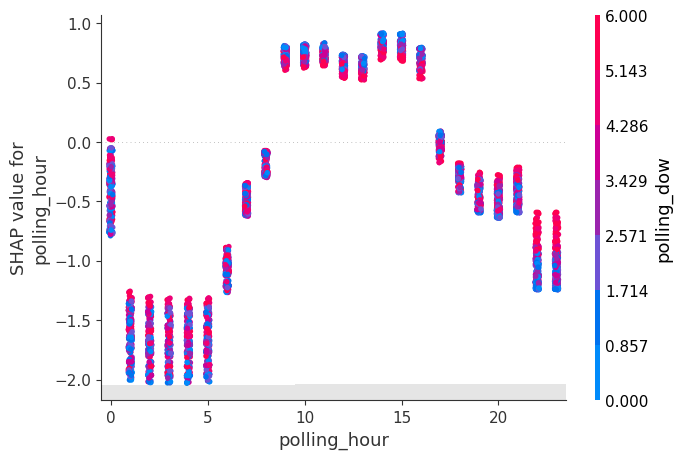

In [40]:
import shap
explainer = shap.TreeExplainer(final_model)   # raw margin = log-odds
sv = explainer(X_test)                   # X_eval = held-out sample
shap.plots.beeswarm(sv)
shap.plots.scatter(sv[:, "polling_hour"], color=sv[:, "polling_dow"])
# older shap: shap.summary_plot(explainer.shap_values(X_eval), X_eval)